Environment ready!
NumPy: 2.3.3
pandas: 2.3.2
scikit-learn: 1.7.2

--- Available Columns ---
['StudentID', 'G1', 'G2', 'G3', 'Mjob', 'Fjob', 'age', 'address', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'passed']
-------------------------

--- Mean stats by passing status ---
        studytime        G1        G2
passed                               
No       2.203704  9.703704  9.388889
Yes      2.217391  8.195652  7.913043
------------------------------------



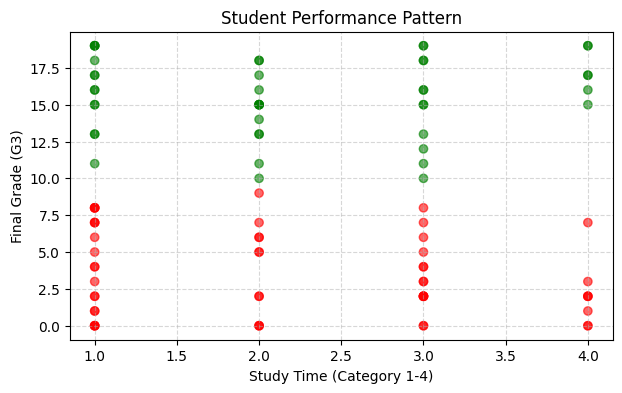

X shape: (100, 4)
y shape: (100,)
Training rows: 80
Testing rows : 20

Model trained successfully!
Test Accuracy: 40.00%


In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

df = pd.read_csv("C:/Users/Akshar Singh/Desktop/student_performance.csv")

df.columns = df.columns.str.strip()

# 2. Create a classification target column ('passed') based on final grade G3
# G3 grades typically range from 0-20. 10+ is a standard passing mark.
df['passed'] = np.where(df['G3'] >= 10, 'Yes', 'No')

print("\n--- Available Columns ---")
print(df.columns.tolist())
print("-------------------------\n")

# 3. Group data by our new 'passed' target and calculate mean values
print("--- Mean stats by passing status ---")
print(df.groupby("passed")[["studytime", "G1", "G2"]].mean())
print("------------------------------------\n")

# 4. Visualise the data pattern (Study Time vs Final Grade G3, coloured by Pass/Fail)
plt.figure(figsize=(7, 4))
scatter = plt.scatter(df["studytime"], df["G3"], c=df['passed'].map({'Yes': 'green', 'No': 'red'}), alpha=0.6)
plt.xlabel("Study Time (Category 1-4)")
plt.ylabel("Final Grade (G3)")
plt.title("Student Performance Pattern")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 5. Split features (X) and target variable (y)
# Selecting available numeric features that influence performance
X = df[["studytime", "age", "G1", "G2"]]
y = df["passed"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 6. Train/Test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

# 7. Define and train the Decision Tree model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully!")

# 8. Quick evaluation to verify it works
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")


In [2]:
predictions = model.predict(X_test)
print('Predictions: ')
print(predictions)
print("X_test: ")
print(X_test)

Predictions: 
['No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes']
X_test: 
    studytime  age  G1  G2
36          1   21  17   5
18          3   21  11  12
71          2   18  12  16
60          4   15   3  16
11          1   18   2   4
26          3   20  19  12
39          1   16  19  19
43          1   19   7   0
33          1   17  17   1
41          1   18   6   6
78          4   17   0   1
2           1   20  14   7
98          4   17  15   3
95          3   15  11  15
16          1   18   0  14
31          2   21   8   6
17          2   19  11   9
53          3   16   5   0
73          3   17  14   1
77          2   21   8  18


In [3]:
accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy: {accuracy:.0%}")

Test Accuracy: 40%


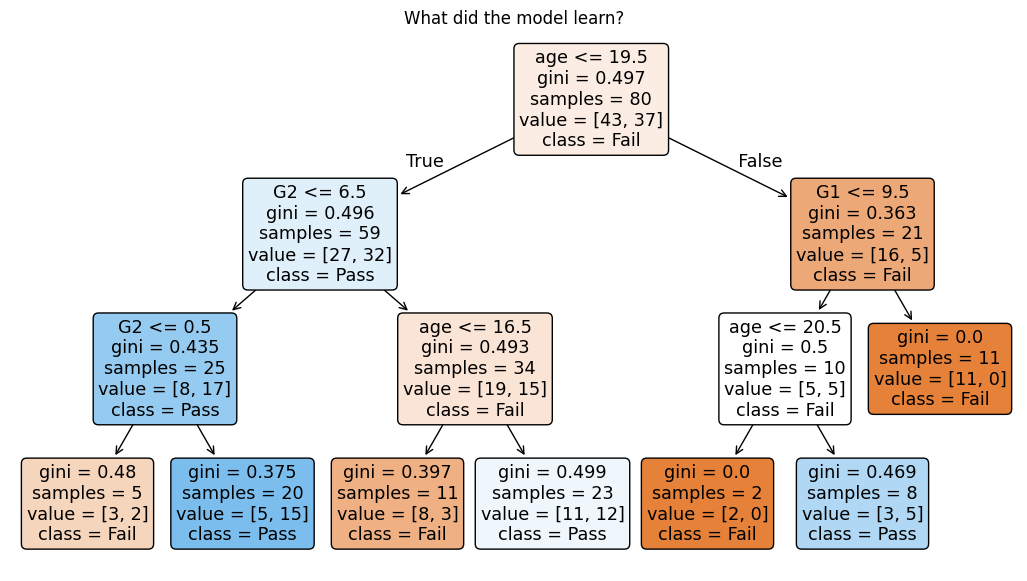

In [9]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# =====================================================================
# STEP 1: Prepare Sample Data (In-Memory Dataset)
# =====================================================================
# We define simple email subjects and label them as 0 (Ham/Safe) or 1 (Spam)
emails = [
    "Meeting schedule for tomorrow project review",  # Safe (0)
    "WIN FREE CASH NOW! CLICK HERE!",  # Spam (1)
    "Please send the engineering lab report by Friday",  # Safe (0)
    "Claim your free prize money today",  # Spam (1)
    "Urgent account verification required",  # Safe (0)
    "CONGRATULATIONS! You won a brand new car",  # Spam (1)
]

labels = [0, 1, 0, 1, 0, 1]  # 0 = Normal Email, 1 = Spam Email

# =====================================================================
# STEP 2: Feature Extraction (Convert Text to Numbers)
# =====================================================================
# Machine Learning algorithms work on numbers, not raw text.
# CountVectorizer counts how many times each word appears in each email.
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# =====================================================================
# STEP 3: Train the Machine Learning Model
# =====================================================================
# We use Naive Bayes, a classic, fast algorithm for text classification.
model = MultinomialNB()
model.fit(X, labels)

print("--- Model Training Complete! ---\n")

# =====================================================================
# STEP 4: Test the Model on Unseen Email Subjects
# =====================================================================
new_emails = [
    "Submit your lab assignment tomorrow",  # Expected: Safe
    "Win a free prize and cash bonus now",  # Expected: Spam
]

# Convert new text to the exact same numerical format
X_new = vectorizer.transform(new_emails)

# Make predictions
predictions = model.predict(X_new)

# Display Results
for email, pred in zip(new_emails, predictions):
    status = "SPAM 🚨" if pred == 1 else "SAFE / NORMAL 🟢"
    print(f"Email   : '{email}'")
    print(f"Result  : {status}\n")

--- Model Training Complete! ---

Email   : 'Submit your lab assignment tomorrow'
Result  : SAFE / NORMAL 🟢

Email   : 'Win a free prize and cash bonus now'
Result  : SPAM 🚨



In [1]:
import os
print(os.getcwd())


C:\Users\Akshar Singh\Documents\New project\android-app
